# **Dataset Engineering & EDA**

**Dataset:** COCO-Text v2  
**Goals:**
- Compute dataset statistics: legibility, language distribution, text length
- Analyze bounding box geometry: size, aspect ratio, spatial distribution
- Produce engineering insights to inform model selection
- Justify confidence threshold selection for TTS gating
- Document all data-driven scope decisions

## 1. Imports & Configuration

In [1]:
import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Reproducibility — fix seed so notebook re-runs produce identical output
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Paths & Data Loading

In [2]:
DATA_ROOT     = Path("../data/raw").resolve()
COCO_IMG_DIR  = DATA_ROOT / "train2014"
COCOTEXT_JSON = DATA_ROOT / "cocotext.v2.json"

# Sanity check paths exist
assert DATA_ROOT.exists(),     f"Data root not found: {DATA_ROOT}"
assert COCO_IMG_DIR.exists(),  f"Image dir not found: {COCO_IMG_DIR}"
assert COCOTEXT_JSON.exists(), f"JSON not found: {COCOTEXT_JSON}"

print("Data root :", DATA_ROOT)
print("Images    :", COCO_IMG_DIR)
print("JSON      :", COCOTEXT_JSON)

Data root : C:\dev\vision-ocr-accessibility-assistant\data\raw
Images    : C:\dev\vision-ocr-accessibility-assistant\data\raw\train2014
JSON      : C:\dev\vision-ocr-accessibility-assistant\data\raw\cocotext.v2.json


In [3]:
def to_int(x):
    """Coerce string keys to int where possible (COCO-Text uses string IDs)."""
    try:
        return int(x)
    except (ValueError, TypeError):
        return x


with open(COCOTEXT_JSON, "r", encoding="utf-8") as f:
    cocotext = json.load(f)

# Normalize all keys to int
imgs      = {to_int(k): v for k, v in cocotext["imgs"].items()}
anns      = {to_int(k): v for k, v in cocotext["anns"].items()}
imgToAnns = {to_int(k): [to_int(a) for a in v] for k, v in cocotext["imgToAnns"].items()}

print(f"Images indexed : {len(imgs):,}")
print(f"Annotations    : {len(anns):,}")
print(f"imgToAnns keys : {len(imgToAnns):,}")

Images indexed : 53,686
Annotations    : 201,126
imgToAnns keys : 53,686


## 3. Quick Visual Sanity Check

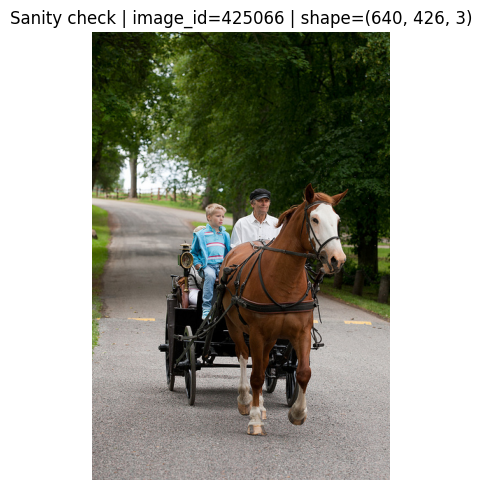

In [4]:
# Show one random image to confirm paths and image loading work
# SEED is already set above — result is reproducible
sample_id   = random.choice(list(imgToAnns.keys()))
img_info    = imgs[sample_id]
img_path    = COCO_IMG_DIR / img_info["file_name"]

assert img_path.exists(), f"Image not found: {img_path}"

img_array = plt.imread(str(img_path))

plt.figure(figsize=(8, 5))
plt.imshow(img_array)
plt.axis("off")
plt.title(f"Sanity check | image_id={sample_id} | shape={img_array.shape}")
plt.tight_layout()
plt.show()

## 4. Annotation Quality & Bounding Box Validation

In [5]:
def bbox_quality_report(imgs, anns):
    """
    Full annotation quality audit.
    Returns a dict of counts for downstream use.
    """
    total        = 0
    invalid_fmt  = 0   # missing bbox or wrong length
    zero_area    = 0   # w <= 0 or h <= 0
    no_image_ref = 0   # annotation points to unknown image_id
    out_of_bounds = 0  # bbox extends beyond image dimensions

    for ann in anns.values():
        bbox = ann.get("bbox")

        if not bbox or len(bbox) != 4:
            invalid_fmt += 1
            continue

        x, y, w, h = bbox
        total += 1

        if w <= 0 or h <= 0:
            zero_area += 1
            continue

        image_id = to_int(ann.get("image_id", -1))
        im = imgs.get(image_id)
        if im is None:
            no_image_ref += 1
            continue

        W, H = im["width"], im["height"]
        if x < 0 or y < 0 or (x + w) > W or (y + h) > H:
            out_of_bounds += 1

    valid = total - zero_area - no_image_ref
    print(f"Total bboxes        : {total:,}")
    print(f"Invalid format      : {invalid_fmt:,}")
    print(f"Zero-area bboxes    : {zero_area:,}")
    print(f"Unknown image ref   : {no_image_ref:,}")
    print(f"Out-of-bounds bboxes: {out_of_bounds:,}  ({out_of_bounds/total*100:.1f}%)  → must be clipped")
    print(f"Usable bboxes       : {valid:,}")

    return dict(total=total, invalid_fmt=invalid_fmt, zero_area=zero_area,
                no_image_ref=no_image_ref, out_of_bounds=out_of_bounds, valid=valid)


bbox_audit = bbox_quality_report(imgs, anns)

Total bboxes        : 201,126
Invalid format      : 0
Zero-area bboxes    : 0
Unknown image ref   : 0
Out-of-bounds bboxes: 5,501  (2.7%)  → must be clipped
Usable bboxes       : 201,126


## 5. Legibility & Language Distribution

In [6]:
# ── Compute once, reuse everywhere ──────────────────────────────────────────
legibility_counts = Counter(
    str(ann.get("legibility", "unknown")).strip().lower()
    for ann in anns.values()
)

language_counts = Counter(
    str(ann.get("language", "unknown")).strip().lower()
    for ann in anns.values()
)

total_anns = len(anns)

print("── Legibility ──")
for k, v in legibility_counts.most_common():
    print(f"  {k:<12}: {v:>7,}  ({v/total_anns*100:.1f}%)")

print("\n── Language ──")
for k, v in language_counts.most_common():
    print(f"  {k:<14}: {v:>7,}  ({v/total_anns*100:.1f}%)")

── Legibility ──
  illegible   : 120,282  (59.8%)
  legible     :  80,844  (40.2%)

── Language ──
  english       : 193,800  (96.4%)
  not english   :   7,326  (3.6%)


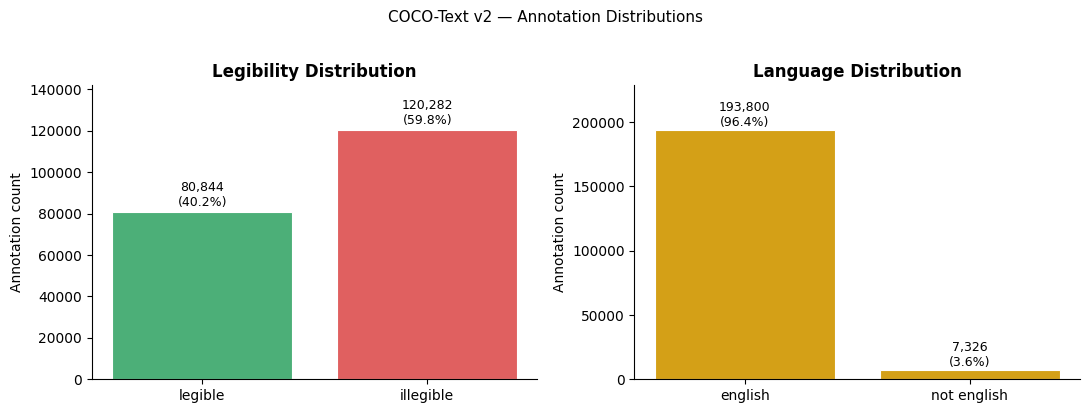

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Legibility
ax = axes[0]
labels_leg = list(legibility_counts.keys())
vals_leg   = list(legibility_counts.values())
colors_leg = ["#4caf78" if l == "legible" else "#e06060" for l in labels_leg]
bars = ax.bar(labels_leg, vals_leg, color=colors_leg, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, vals_leg):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f"{val:,}\n({val/total_anns*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Legibility Distribution", fontweight="bold")
ax.set_ylabel("Annotation count")
ax.set_ylim(0, max(vals_leg) * 1.18)
ax.spines[["top", "right"]].set_visible(False)

# Language
ax = axes[1]
labels_lang = list(language_counts.keys())
vals_lang   = list(language_counts.values())
colors_lang = ["#d4a017" if "english" in l else "#5090d0" for l in labels_lang]
bars = ax.bar(labels_lang, vals_lang, color=colors_lang, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, vals_lang):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f"{val:,}\n({val/total_anns*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Language Distribution", fontweight="bold")
ax.set_ylabel("Annotation count")
ax.set_ylim(0, max(vals_lang) * 1.18)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("COCO-Text v2 — Annotation Distributions", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

## 6. Bounding Box Geometry

In [8]:
# ── Build vectorized arrays for all valid bboxes ────────────────────────────
bbox_data = []

for ann in anns.values():
    bbox = ann.get("bbox")
    if not bbox or len(bbox) != 4:
        continue
    x, y, w, h = bbox
    if w <= 0 or h <= 0:
        continue
    image_id = to_int(ann.get("image_id", -1))
    im = imgs.get(image_id)
    if im is None:
        continue
    W, H = im["width"], im["height"]
    if W <= 0 or H <= 0:
        continue
    bbox_data.append({
        "x": x, "y": y, "w": w, "h": h,
        "W": W, "H": H,
        "area": w * h,
        "area_ratio": (w * h) / (W * H),
        "aspect": w / h,
        "cx_norm": (x + w / 2) / W,   # normalized centroid x
        "cy_norm": (y + h / 2) / H,   # normalized centroid y
    })

# Convert to numpy for fast vectorized operations
areas        = np.array([d["area"]        for d in bbox_data])
area_ratios  = np.array([d["area_ratio"]  for d in bbox_data])
aspects      = np.array([d["aspect"]      for d in bbox_data])
cx_norm      = np.array([d["cx_norm"]     for d in bbox_data])
cy_norm      = np.array([d["cy_norm"]     for d in bbox_data])

print(f"Valid bboxes for geometry analysis: {len(areas):,}")

# ── Area statistics ──
pcts = np.percentile(areas, [0, 1, 5, 25, 50, 75, 95, 99, 100])
labels_pct = ["min", "p1", "p5", "p25", "median", "p75", "p95", "p99", "max"]
print("\n── BBox absolute area (px²) percentiles ──")
for l, v in zip(labels_pct, pcts):
    print(f"  {l:<8}: {v:>10.1f} px²")

# Mean is misleading for skewed distributions — always report median alongside
print(f"\n  mean   : {np.mean(areas):>10.1f} px²  (pulled up by outliers)")
print(f"  median : {np.median(areas):>10.1f} px²  (more representative)")
print(f"\n  < 1000 px²: {np.sum(areas < 1000):,}  ({np.mean(areas < 1000)*100:.1f}% of bboxes)")

Valid bboxes for geometry analysis: 201,126

── BBox absolute area (px²) percentiles ──
  min     :        0.8 px²
  p1      :       13.2 px²
  p5      :       27.3 px²
  p25     :       83.5 px²
  median  :      194.4 px²
  p75     :      499.0 px²
  p95     :     2515.3 px²
  p99     :     9050.7 px²
  max     :   239869.1 px²

  mean   :      707.9 px²  (pulled up by outliers)
  median :      194.4 px²  (more representative)

  < 1000 px²: 174,478  (86.8% of bboxes)


── BBox area ratio (w*h)/(W*H) percentiles ──
  min     : 0.000003
  p1      : 0.000048
  p5      : 0.000098
  p25     : 0.000302
  median  : 0.000705
  p75     : 0.001830
  p95     : 0.009167
  p99     : 0.033173
  max     : 0.879801


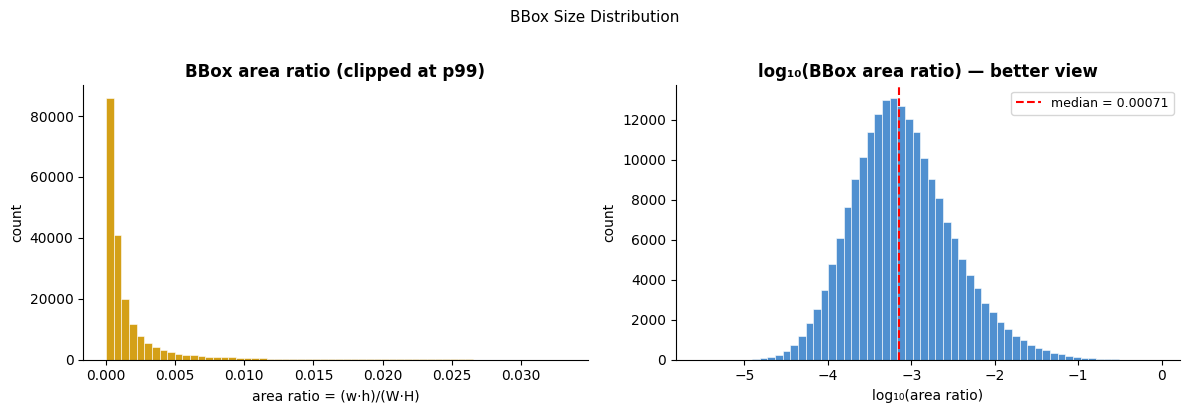

In [9]:
# ── Area ratio percentiles ───────────────────────────────────────────────────
ratio_pcts = np.percentile(area_ratios, [0, 1, 5, 25, 50, 75, 95, 99, 100])
print("── BBox area ratio (w*h)/(W*H) percentiles ──")
for l, v in zip(labels_pct, ratio_pcts):
    print(f"  {l:<8}: {v:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear histogram (clipped at p99 to keep readable)
clip_hi = np.percentile(area_ratios, 99)
axes[0].hist(area_ratios[area_ratios <= clip_hi], bins=60, color="#d4a017", edgecolor="white", linewidth=0.4)
axes[0].set_title("BBox area ratio (clipped at p99)", fontweight="bold")
axes[0].set_xlabel("area ratio = (w·h)/(W·H)")
axes[0].set_ylabel("count")
axes[0].spines[["top", "right"]].set_visible(False)

# Log histogram — best view for heavily skewed distribution
axes[1].hist(np.log10(area_ratios), bins=60, color="#5090d0", edgecolor="white", linewidth=0.4)
axes[1].axvline(np.log10(np.median(area_ratios)), color="red", linestyle="--", linewidth=1.5,
                label=f"median = {np.median(area_ratios):.5f}")
axes[1].set_title("log₁₀(BBox area ratio) — better view", fontweight="bold")
axes[1].set_xlabel("log₁₀(area ratio)")
axes[1].set_ylabel("count")
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("BBox Size Distribution", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

Aspect ratio (w/h) stats:
  median : 1.74
  mean   : 2.13
  > 3 (wide): 20.8% of bboxes
  < 0.5 (tall): 4.8% of bboxes


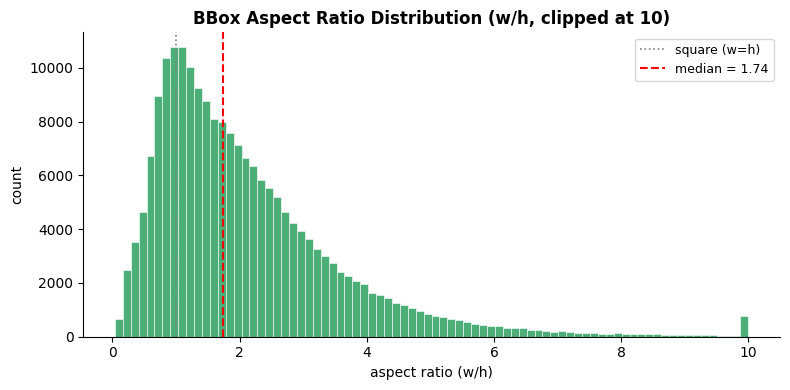

In [10]:
# ── Aspect ratio distribution ────────────────────────────────────────────────
# Clipped at 10 for readability (very tall/wide outliers exist)
aspects_clip = np.clip(aspects, 0, 10)

print(f"Aspect ratio (w/h) stats:")
print(f"  median : {np.median(aspects):.2f}")
print(f"  mean   : {np.mean(aspects):.2f}")
print(f"  > 3 (wide): {np.mean(aspects > 3)*100:.1f}% of bboxes")
print(f"  < 0.5 (tall): {np.mean(aspects < 0.5)*100:.1f}% of bboxes")

plt.figure(figsize=(8, 4))
plt.hist(aspects_clip, bins=80, color="#4caf78", edgecolor="white", linewidth=0.4)
plt.axvline(1.0, color="gray", linestyle=":", linewidth=1.2, label="square (w=h)")
plt.axvline(np.median(aspects), color="red", linestyle="--", linewidth=1.5,
            label=f"median = {np.median(aspects):.2f}")
plt.title("BBox Aspect Ratio Distribution (w/h, clipped at 10)", fontweight="bold")
plt.xlabel("aspect ratio (w/h)")
plt.ylabel("count")
plt.legend(fontsize=9)
plt.spines = plt.gca().spines
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

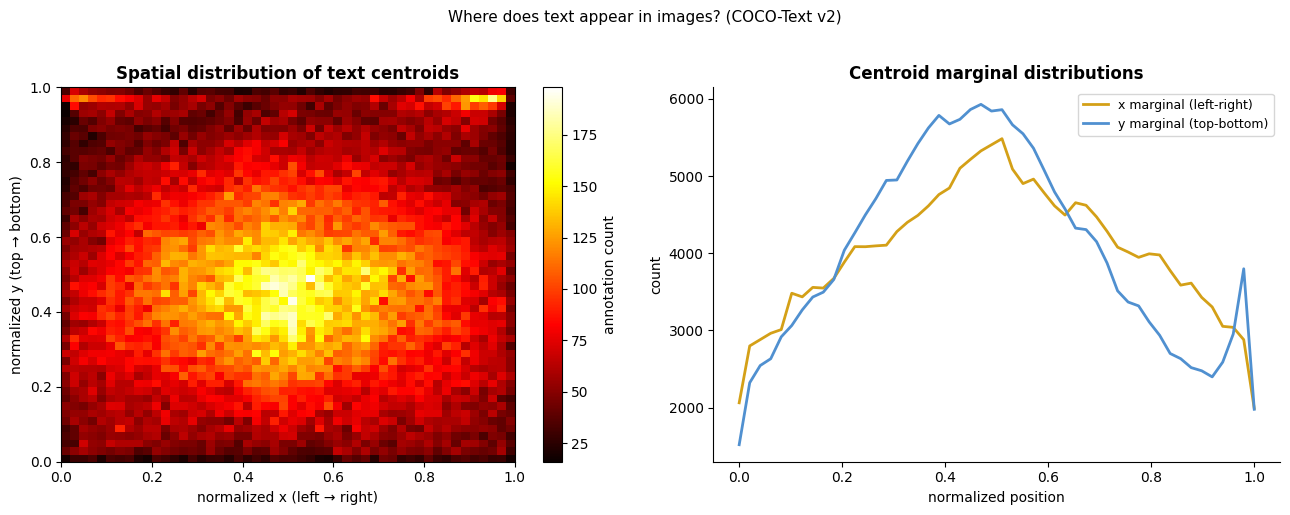

In [11]:
# ── Spatial distribution of text centroids ───────────────────────────────────
# Where in the image does text tend to appear?
# Important for detection model design and cropping strategy.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 2D heatmap
h2d, xedges, yedges = np.histogram2d(cx_norm, cy_norm, bins=50,
                                      range=[[0, 1], [0, 1]])
im = axes[0].imshow(h2d.T, origin="lower", aspect="auto",
                    extent=[0, 1, 0, 1], cmap="hot")
plt.colorbar(im, ax=axes[0], label="annotation count")
axes[0].set_title("Spatial distribution of text centroids", fontweight="bold")
axes[0].set_xlabel("normalized x (left → right)")
axes[0].set_ylabel("normalized y (top → bottom)")

# Marginal distributions
axes[1].plot(np.linspace(0, 1, 50), h2d.sum(axis=1), label="x marginal (left-right)",
             color="#d4a017", linewidth=2)
axes[1].plot(np.linspace(0, 1, 50), h2d.sum(axis=0), label="y marginal (top-bottom)",
             color="#5090d0", linewidth=2)
axes[1].set_title("Centroid marginal distributions", fontweight="bold")
axes[1].set_xlabel("normalized position")
axes[1].set_ylabel("count")
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Where does text appear in images? (COCO-Text v2)", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

## 7. Content Difficulty & Text Length

── Text length (characters) ──
  Total annotations     : 201,126
  Empty/missing strings : 126,514
  Non-empty             : 74,612
  Mean length           : 4.40 chars
  Median length         : 4.0 chars
  Max length            : 65 chars
  > 30 chars            : 22
  Single char (=1)      : 11,240  (15.1%)


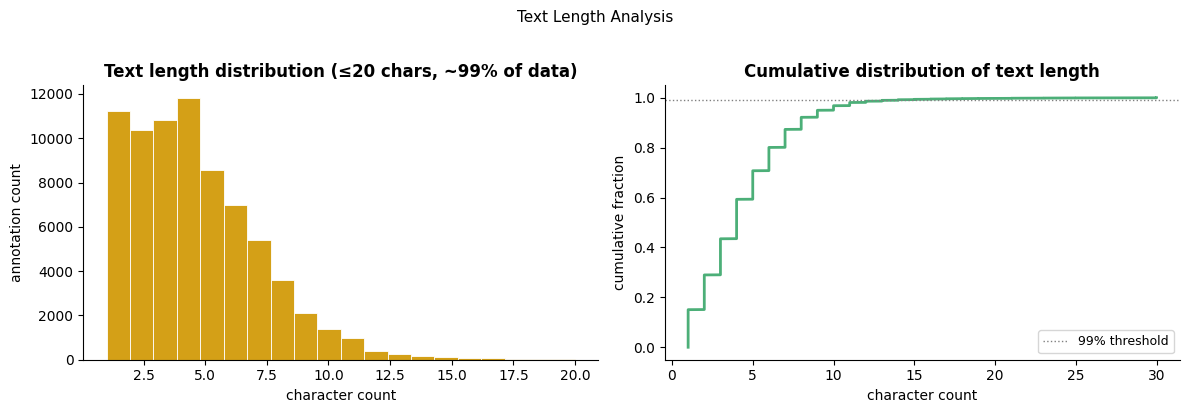

In [12]:
# ── Text length analysis ─────────────────────────────────────────────────────
text_lengths = np.array([
    len(ann.get("utf8_string", "").strip())
    for ann in anns.values()
])

# Only count non-empty strings for mean
nonempty_lengths = text_lengths[text_lengths > 0]

print("── Text length (characters) ──")
print(f"  Total annotations     : {len(text_lengths):,}")
print(f"  Empty/missing strings : {np.sum(text_lengths == 0):,}")
print(f"  Non-empty             : {len(nonempty_lengths):,}")
print(f"  Mean length           : {np.mean(nonempty_lengths):.2f} chars")
print(f"  Median length         : {np.median(nonempty_lengths):.1f} chars")
print(f"  Max length            : {np.max(nonempty_lengths)} chars")
print(f"  > 30 chars            : {np.sum(nonempty_lengths > 30):,}")
print(f"  Single char (=1)      : {np.sum(nonempty_lengths == 1):,}  ({np.mean(nonempty_lengths == 1)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution clipped
axes[0].hist(nonempty_lengths[nonempty_lengths <= 20], bins=20,
             color="#d4a017", edgecolor="white", linewidth=0.6)
axes[0].set_title("Text length distribution (≤20 chars, ~99% of data)", fontweight="bold")
axes[0].set_xlabel("character count")
axes[0].set_ylabel("annotation count")
axes[0].spines[["top", "right"]].set_visible(False)

# Cumulative
sorted_lens = np.sort(nonempty_lengths)
cdf = np.arange(1, len(sorted_lens)+1) / len(sorted_lens)
axes[1].plot(sorted_lens[sorted_lens <= 30], cdf[sorted_lens <= 30],
             color="#4caf78", linewidth=2)
axes[1].axhline(0.99, color="gray", linestyle=":", linewidth=1, label="99% threshold")
axes[1].set_title("Cumulative distribution of text length", fontweight="bold")
axes[1].set_xlabel("character count")
axes[1].set_ylabel("cumulative fraction")
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Text Length Analysis", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

## 8. Confidence Threshold Justification

── Legibility vs. BBox size ──
  Legible   median area: 406 px²
  Illegible median area: 123 px²
  → Illegible text is 3.3x smaller on median


C:\Users\camar\AppData\Local\Temp\ipykernel_35940\2552582088.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bin_labels, rotation=30, ha="right", fontsize=8)


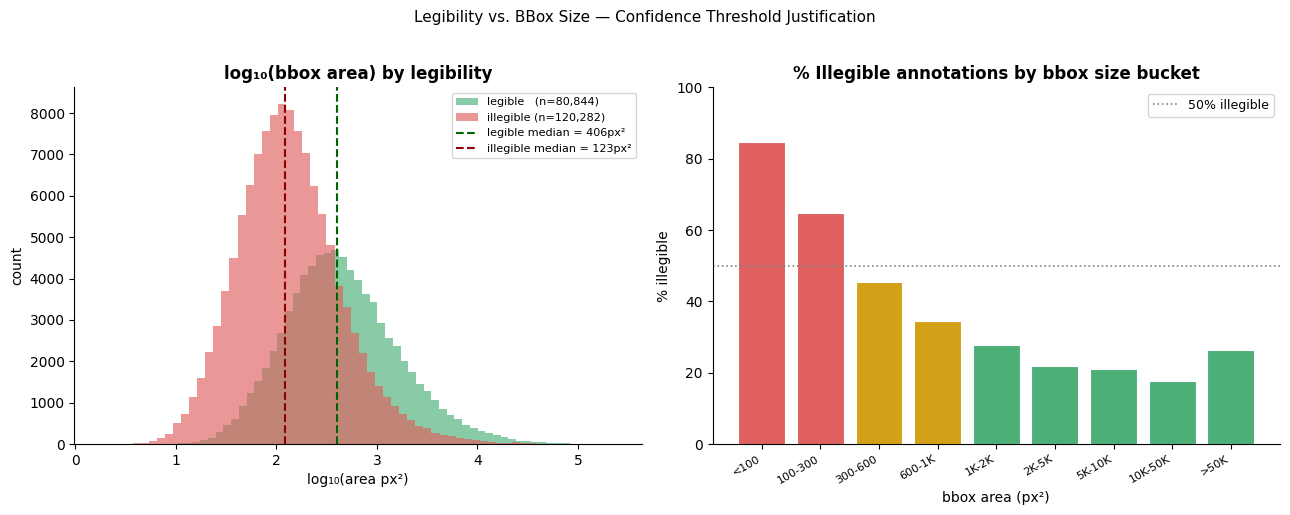


Insight: small bboxes are predominantly illegible.
A confidence threshold of >0.75 will naturally filter most small/unreadable text.


In [13]:
# ── Legibility vs. bbox size ──────────────────────────────────────────────────
# Key plot for Phase 0 decision: justify confidence gate threshold of 0.75
# If illegible annotations cluster at small bbox sizes, small text = low confidence
# → confirms threshold is appropriate and not arbitrary

leg_areas_list   = []
illeg_areas_list = []

for ann in anns.values():
    bbox = ann.get("bbox")
    if not bbox or len(bbox) != 4:
        continue
    w, h = bbox[2], bbox[3]
    if w <= 0 or h <= 0:
        continue
    legibility = str(ann.get("legibility", "")).strip().lower()
    area = w * h
    if legibility == "legible":
        leg_areas_list.append(area)
    elif legibility == "illegible":
        illeg_areas_list.append(area)

leg_areas_arr   = np.array(leg_areas_list)
illeg_areas_arr = np.array(illeg_areas_list)

print("── Legibility vs. BBox size ──")
print(f"  Legible   median area: {np.median(leg_areas_arr):.0f} px²")
print(f"  Illegible median area: {np.median(illeg_areas_arr):.0f} px²")
print(f"  → Illegible text is {np.median(leg_areas_arr)/np.median(illeg_areas_arr):.1f}x smaller on median")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overlapping log histograms
ax = axes[0]
ax.hist(np.log10(leg_areas_arr + 1),   bins=60, alpha=0.65,
        label=f"legible   (n={len(leg_areas_arr):,})",   color="#4caf78")
ax.hist(np.log10(illeg_areas_arr + 1), bins=60, alpha=0.65,
        label=f"illegible (n={len(illeg_areas_arr):,})", color="#e06060")
ax.axvline(np.log10(np.median(leg_areas_arr)),
           color="darkgreen", linestyle="--", linewidth=1.5,
           label=f"legible median = {np.median(leg_areas_arr):.0f}px²")
ax.axvline(np.log10(np.median(illeg_areas_arr)),
           color="darkred", linestyle="--", linewidth=1.5,
           label=f"illegible median = {np.median(illeg_areas_arr):.0f}px²")
ax.set_title("log₁₀(bbox area) by legibility", fontweight="bold")
ax.set_xlabel("log₁₀(area px²)")
ax.set_ylabel("count")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# Fraction illegible by area bucket — the key justification plot
ax = axes[1]
bins = [0, 100, 300, 600, 1000, 2000, 5000, 10000, 50000, np.inf]
bin_labels = ["<100", "100-300", "300-600", "600-1K", "1K-2K", "2K-5K", "5K-10K", "10K-50K", ">50K"]
frac_illeg = []
for lo, hi in zip(bins[:-1], bins[1:]):
    n_leg   = np.sum((leg_areas_arr   >= lo) & (leg_areas_arr   < hi))
    n_illeg = np.sum((illeg_areas_arr >= lo) & (illeg_areas_arr < hi))
    total_b = n_leg + n_illeg
    frac_illeg.append(n_illeg / total_b if total_b > 0 else 0)

colors_bar = ["#e06060" if f > 0.5 else "#d4a017" if f > 0.3 else "#4caf78" for f in frac_illeg]
bars = ax.bar(bin_labels, [f*100 for f in frac_illeg], color=colors_bar,
              edgecolor="white", linewidth=0.8)
ax.axhline(50, color="gray", linestyle=":", linewidth=1.2, label="50% illegible")
ax.set_title("% Illegible annotations by bbox size bucket", fontweight="bold")
ax.set_xlabel("bbox area (px²)")
ax.set_ylabel("% illegible")
ax.set_xticklabels(bin_labels, rotation=30, ha="right", fontsize=8)
ax.set_ylim(0, 100)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Legibility vs. BBox Size — Confidence Threshold Justification", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print("\nInsight: small bboxes are predominantly illegible.")
print("A confidence threshold of >0.75 will naturally filter most small/unreadable text.")

## 9. Legible Image Viewer

In [14]:
# ── Precompute legible image list ONCE ───────────────────────────────────────
# Previously this was rebuilt on every function call — now computed once and reused
LEGIBLE_IMAGE_IDS = [
    img_id
    for img_id, ann_ids in imgToAnns.items()
    if any(
        str(anns[a].get("legibility", "")).strip().lower() == "legible"
        and isinstance(anns[a].get("utf8_string", ""), str)
        and anns[a]["utf8_string"].strip()
        for a in ann_ids
        if a in anns
    )
]

print(f"Images with ≥1 legible annotation: {len(LEGIBLE_IMAGE_IDS):,}")

Images with ≥1 legible annotation: 16,169


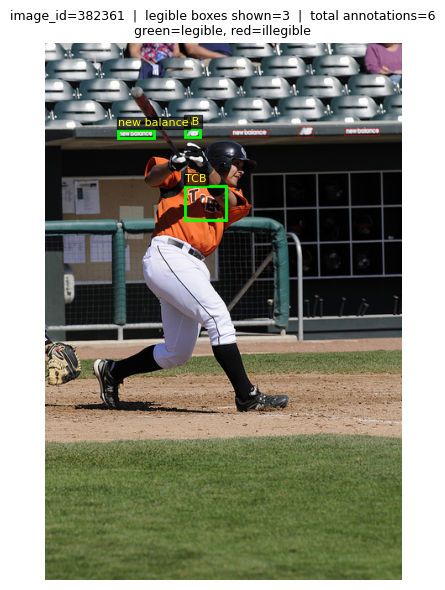

Legible texts: TCB | AB | new balance


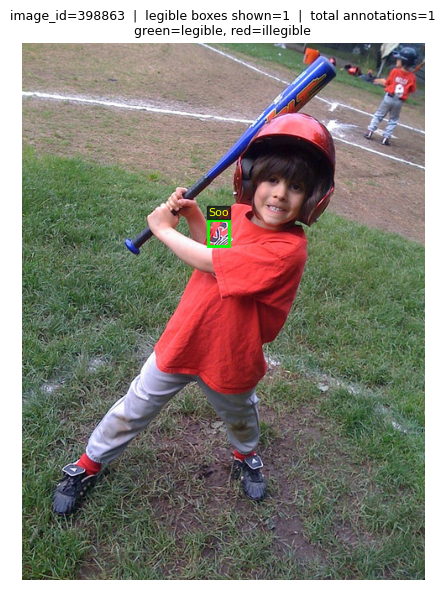

Legible texts: Soo


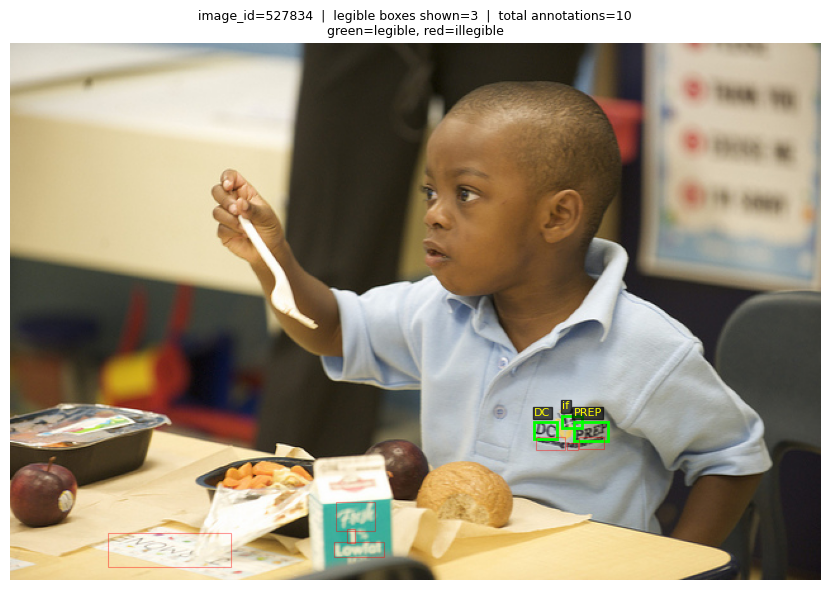

Legible texts: DC | PREP | if


In [15]:
def show_legible_sample(image_id, image_root, max_boxes=30):
    """
    Display a single image with legible bounding boxes overlaid.
    Separates legible (green) and illegible (red, dimmed) for visual contrast.
    """
    img_info  = imgs.get(image_id)
    if img_info is None:
        print(f"Image metadata not found for id={image_id}")
        return

    img_path = Path(image_root) / img_info["file_name"]
    if not img_path.exists():
        print(f"Image file not found: {img_path}")
        return

    img_pil = Image.open(img_path).convert("RGB")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(img_pil)
    ax.axis("off")

    legible_texts = []
    shown = 0

    for ann_id in imgToAnns.get(image_id, []):
        ann = anns.get(ann_id)
        if ann is None:
            continue
        bbox = ann.get("bbox")
        if not bbox or len(bbox) != 4:
            continue

        x, y, w, h   = bbox
        legibility   = str(ann.get("legibility", "")).strip().lower()
        text         = ann.get("utf8_string", "").strip()
        is_legible   = legibility == "legible" and text

        color     = "lime"   if is_legible else "red"
        linewidth = 2.0      if is_legible else 0.8
        alpha     = 1.0      if is_legible else 0.4

        ax.add_patch(patches.Rectangle(
            (x, y), w, h,
            linewidth=linewidth, edgecolor=color,
            facecolor="none", alpha=alpha
        ))

        if is_legible and shown < max_boxes:
            ax.text(x, max(y - 5, 0), text,
                    fontsize=8, color="yellow",
                    bbox=dict(facecolor="black", alpha=0.65, pad=1))
            legible_texts.append(text)
            shown += 1

    n_total = len(imgToAnns.get(image_id, []))
    ax.set_title(
        f"image_id={image_id}  |  legible boxes shown={shown}  |  total annotations={n_total}\n"
        f"green=legible, red=illegible",
        fontsize=9
    )
    plt.tight_layout()
    plt.show()
    print("Legible texts:", " | ".join(legible_texts) if legible_texts else "(none)")


# Show 3 samples — LEGIBLE_IMAGE_IDS already computed, no repeated loops
sample_ids = random.sample(LEGIBLE_IMAGE_IDS, 3)
for sid in sample_ids:
    show_legible_sample(sid, COCO_IMG_DIR)

## 10. Summary Statistics & Engineering Insights

In [17]:
# ── Consolidated summary — single source of truth for the report ─────────────
n_legible   = legibility_counts.get("legible", 0)
n_illegible = legibility_counts.get("illegible", 0)
n_english   = language_counts.get("english", 0)
n_not_en    = language_counts.get("not english", 0)
n_small_bb  = int(np.sum(areas < 1000))
n_long_text = int(np.sum(nonempty_lengths > 30))
n_oob       = bbox_audit["out_of_bounds"]
n_illeg_img = sum(
    any(anns[a].get("legibility") == "illegible" for a in v if a in anns)
    for v in imgToAnns.values()
)

print("=" * 55)
print("  COCO-Text v2 — EDA Summary")
print("=" * 55)
print(f"  Total annotations          : {total_anns:>10,}")
print(f"  Images indexed             : {len(imgs):>10,}")
print(f"  Images w/ legible text     : {len(LEGIBLE_IMAGE_IDS):>10,}  ({len(LEGIBLE_IMAGE_IDS)/len(imgs)*100:.1f}%)")
print()
print(f"  Legible annotations        : {n_legible:>10,}  ({n_legible/total_anns*100:.1f}%)")
print(f"  Illegible annotations      : {n_illegible:>10,}  ({n_illegible/total_anns*100:.1f}%)")
print()
print(f"  English annotations        : {n_english:>10,}  ({n_english/total_anns*100:.1f}%)")
print(f"  Non-English annotations    : {n_not_en:>10,}  ({n_not_en/total_anns*100:.1f}%)")
print()
print(f"  Bbox area — mean           : {np.mean(areas):>10.1f} px²  (skewed by outliers)")
print(f"  Bbox area — median         : {np.median(areas):>10.1f} px²  (representative)")
print(f"  Small bboxes (<1000 px²)   : {n_small_bb:>10,}  ({n_small_bb/len(areas)*100:.1f}%)")
print(f"  Out-of-bounds bboxes       : {n_oob:>10,}  ({n_oob/total_anns*100:.1f}%)  → clip required")
print()
print(f"  Mean text length           : {np.mean(nonempty_lengths):>10.2f} chars")
print(f"  Long texts (>30 chars)     : {n_long_text:>10,}")
print(f"  Images w/ illegible text   : {n_illeg_img:>10,}")

  COCO-Text v2 — EDA Summary
  Total annotations          :    201,126
  Images indexed             :     53,686
  Images w/ legible text     :     16,169  (30.1%)

  Legible annotations        :     80,844  (40.2%)
  Illegible annotations      :    120,282  (59.8%)

  English annotations        :    193,800  (96.4%)
  Non-English annotations    :      7,326  (3.6%)

  Bbox area — mean           :      707.9 px²  (skewed by outliers)
  Bbox area — median         :      194.4 px²  (representative)
  Small bboxes (<1000 px²)   :    174,478  (86.8%)
  Out-of-bounds bboxes       :      5,501  (2.7%)  → clip required

  Mean text length           :       4.40 chars
  Long texts (>30 chars)     :         22
  Images w/ illegible text   :     19,974


# **EDA Summary**

---

- Total annotations: **201,126**
- Images indexed: **53,686**
- Images w/ legible text: **16,169** (**30.1%**)

- Legible annotations: **80,844** (**40.2%**)
- Illegible annotations: **120,282** (**59.8%**)

- English annotations: **193,800** (**96.4%**)
- Non-English annotations: **7,326** (**3.6%**)

- Bbox area - mean: **707.9 px^2** (skewed by outliers)
- Bbox area - median: **194.4 px^2** (representative)
- Small bboxes (<1000 px^2): **174,478** (**86.8%**)
- Out-of-bounds bboxes: **5,501** (**2.7%**) -> clip required

- Mean text length: **4.40 chars**
- Long texts (>30 chars): **22**
- Images w/ illegible text: **19,974**

---

## **Engineering Insights**

1. English-only MVP is justified: **96.4%** of annotations are English.
2. Confidence gating is essential: **59.8%** of annotations are illegible.
3. Small-text performance is critical: **86.8%** of bboxes are `< 1000 px^2`.
4. OOB clip required before training: **5,501** bboxes exceed image bounds.
5. TTS fragment grouping needed: average text is short and not sentence-like.
6. Illegible text skews smaller, supporting a **0.75 confidence threshold**.
